In [107]:
import numpy as np
import matplotlib.pyplot as plt
import OptimalBattery.util as ut
from Functional_Fusion.dataset import DataSetLanguage
import os
import pickle
import Functional_Fusion.atlas_map as am
from IndividualParcellation.global_config import *
import OptimalBattery.evaluate as ev
import PcmPy as pcm
import seaborn as sns
import nilearn.plotting as plotting
import nitools as nt
import pandas as pd
from Functional_Fusion.util import get_volumes
from scipy.special import softmax
import SUITPy.flatmap as fm



# define atlas for data used and ROI mask dir

In [108]:
space = 'SUIT3'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/FunctionalFusion/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/FunctionalFusion/'
cort_dir = 'Y:/data/Atlas_templates/fs_LR_32'

In [109]:
model_dir = 'Y:/data/Cerebellum/Language/ProbabilisticParcellations/language-localizer_sencoding_fusion_k2_SUIT3.pkl'
with open(model_dir, 'rb') as f:
    full_model = pickle.load(f)

# check object attributes
log_pi = full_model.arrange.logpi.cpu().numpy()
probabilities = softmax(log_pi, axis=0)




<Axes: >

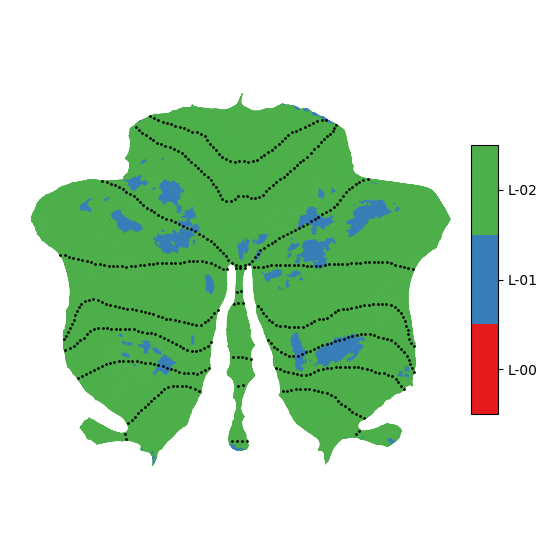

In [110]:
probabilities_reshaped = probabilities.reshape(1, probabilities.shape[0], probabilities.shape[1])
vol= get_volumes(probabilities_reshaped,atlas_name = 'SUIT3')
surf= fm.vol_to_surf(vol, space='SUIT')
label = np.argmax(surf, axis=1) + 1
label = label.reshape( label.shape[0],1)
fm.plot(data=label,overlay_type='label',cmap='Set1',colorbar=True)
# label.shape

<class 'HierarchBayesParcel.full_model.FullMultiModel'>
torch.Size([18, 2])
torch.Size([14, 2])


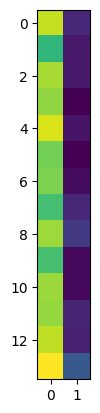

In [123]:
print(type(full_model))
print(full_model.emissions[0].V.shape)
print(full_model.emissions[1].V.shape)

langloc_Vs = full_model.emissions[0].V.cpu().numpy()[1:,:]
langsencoding_Vs = full_model.emissions[1].V.cpu().numpy()

plt.imshow(langsencoding_Vs)

1:Action Obser  
2:sociolinguistic  
3:motor  
4:working memory  

# Load data

In [124]:
Language_dataset = DataSetLanguage('/cifs/diedrichsen/data/FunctionalFusion/Language')
if not os.path.exists('/cifs/diedrichsen/data/FunctionalFusion/Language'):
    Language_dataset = DataSetLanguage('Y:/data/FunctionalFusion/Language')


subj_list = ['sub-02','sub-03','sub-07','sub-09','sub-10','sub-12','sub-13']
data_langloc_run, info_langloc_run = Language_dataset.get_data(space= space, ses_id='ses-localizer_cond',type='CondRun',subj=subj_list)
data_langloc_run[np.isnan(data_langloc_run)] = 0
#remove all spaces in taskName column
info_langloc_run['taskName'] = info_langloc_run['taskName'].str.replace(' ', '')

data_langloc_all, info_langloc_all = Language_dataset.get_data(space= space, ses_id='ses-localizer_cond',type='CondAll',subj=subj_list)
data_langloc_all[np.isnan(data_langloc_all)] = 0
print(data_langloc_all.shape)
info_langloc_all['taskName'] = info_langloc_all['taskName'].str.replace(' ', '')

data_sencoding_all, info_sencoding_all = Language_dataset.get_data(space= space, ses_id='ses-sencoding_category_duration',type='CondAll',subj=subj_list)
data_sencoding_all[np.isnan(data_sencoding_all)] = 0

(7, 18, 6918)


In [125]:
# recenter data (agianst rest)
data_langloc_run,info_langloc_run = ut.recenter_fmri_data(data_langloc_run,info_langloc_run,task_column_name='taskName',center_condition='rest')
print(data_langloc_run.shape)
print(data_langloc_run[0][0])

(7, 136, 6918)
[0.36050278 0.39331551 0.328436   ... 0.6210311  0.67170614 0.73598096]


In [126]:
data_langloc_all,info_langloc_all = ut.recenter_fmri_data(data_langloc_all,info_langloc_all,task_column_name='taskName',center_condition='rest')
print(data_langloc_all.shape)
print(data_langloc_all[0][0])

(7, 17, 6918)
[0.03709233 0.03724284 0.0623692  ... 0.33741066 0.263305   0.17052875]


In [89]:
# data_sencoding_all,info_sencoding_all = ut.recenter_fmri_data(data_sencoding_all,info_sencoding_all,task_column_name='names',center_condition='simple')
# print(data_sencoding_all.shape)
# info_sencoding_all

(7, 13, 6918)


,reg_id,n_rep,Unnamed: 0,taskName,task,inst,instOrder,time,sess,names
0,2,20.0,287,simple_Speed,2,0,0,1.1,1,simple_Speed
1,3,20.0,288,bigram,3,0,0,1.1,1,bigram
2,4,20.0,289,wordlist,4,0,0,1.1,1,wordlist
3,5,20.0,290,ambiguity_immed,5,0,0,1.1,1,ambiguity_immed
4,6,20.0,291,ambiguity_delay,6,0,0,1.1,1,ambiguity_delay
5,7,20.0,292,HE,7,0,0,1.1,1,HE
6,8,20.0,293,LE,8,0,0,1.1,1,LE
7,9,20.0,294,MSM,9,0,0,1.1,1,MSM
8,10,20.0,295,MSE,10,0,0,1.1,1,MSE
9,11,20.0,296,CSM_sem,11,0,0,1.1,1,CSM_sem


(6918,)


<Axes: >

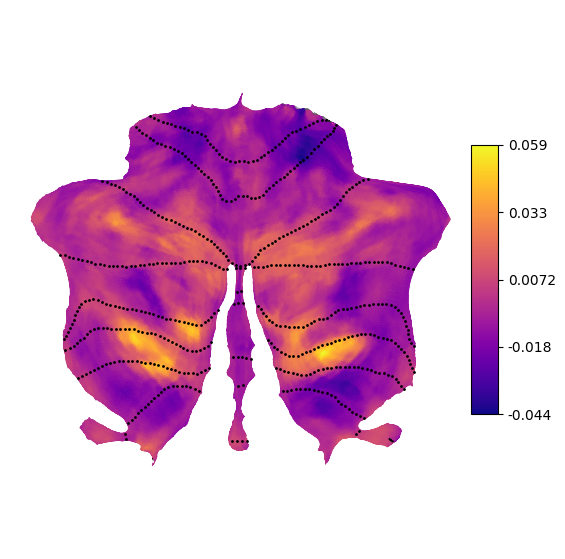

In [127]:
#avg across first and second dimensions
avg = np.mean(data_sencoding_all, axis=(0,1))
print(avg.shape)

# plot cerebellarmap
avg = avg.reshape(1, avg.shape[0])

vol= get_volumes(avg,atlas_name = 'SUIT3')

surf= fm.vol_to_surf(vol, space='SUIT')

fm.plot(data=surf,overlay_type='func',cmap='plasma',colorbar=True)




2076


<Axes: >

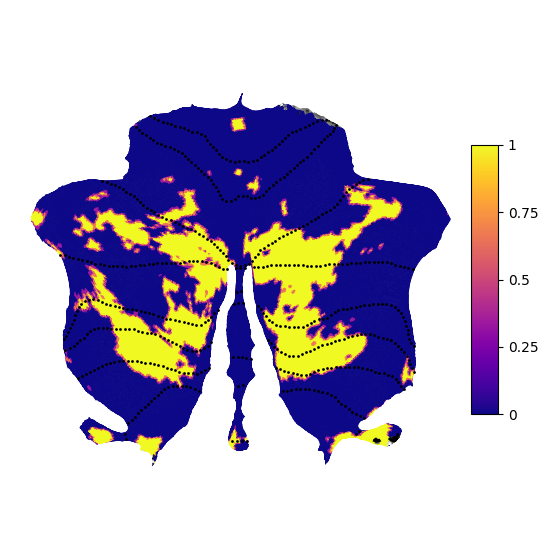

In [128]:
threshold_value = 70

#threshold and get indices of top 10% voxels also plot
threshold = np.percentile(avg, threshold_value)
indices = np.where(avg[0] > threshold)[0]
print(len(indices))

# make avg into 1s and 0s
mask = np.zeros(avg.shape)
mask[0,indices] = 1

vol= get_volumes(mask,atlas_name = 'SUIT3')
surf= fm.vol_to_surf(vol, space='SUIT',stats='mode')
fm.plot(data=surf,overlay_type='func',cmap='plasma',colorbar=True)


# Get crossvalidated second moment matrix (GLib)

In [129]:
task_names = info_langloc_all['names'].unique()
print(task_names)


['word_reading' 'verb_GENERATION' 'action_observation_action'
 'action_observation' 'intact_passage' 'degraded_passage'
 'tongue_movement' 'finger_sequence' 'theory_of_mind' 'auditory_narrative'
 'n_back' 'oddball' 'demand_grid' 'romance_movie' 'spatial_navigation'
 'sentence_reading' 'nonword_reading']


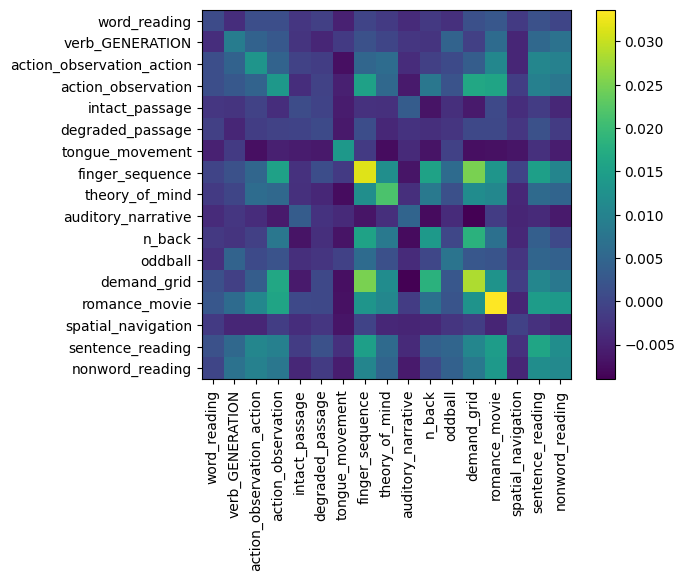

In [130]:
cond_vec = np.tile(np.arange(1, 17 + 1), 8)
part_vec = np.repeat(np.arange(1, 8 + 1), 17)
Gs_list = []
E_list = []
for i in range(data_langloc_run.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_langloc_run[i][:,indices] , cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_Lib = np.mean(Gs_list, axis=0)

# plt.imshow with task names on x and y axis
plt.imshow(G_Lib)
plt.colorbar()
plt.xticks(np.arange(0, 17), task_names, rotation=90)
plt.yticks(np.arange(0, 17), task_names)
plt.show()


In [138]:
D = ut.build_combinations(G_Lib, strategy='random',n_iter=500,n_tasks=6,seed=1,replacement=True)
D_ev = ev.evaluate_dataframe_real_multiregion(D, data_langloc_all,langloc_Vs,data_sencoding_all, langsencoding_Vs,indices)
D_ev = D_ev.reset_index(drop=True)


Processing combination: 0
Processing combination: 10
Processing combination: 20
Processing combination: 30
Processing combination: 40
Processing combination: 50
Processing combination: 60
Processing combination: 70
Processing combination: 80
Processing combination: 90
Processing combination: 100
Processing combination: 110
Processing combination: 120
Processing combination: 130
Processing combination: 140
Processing combination: 150
Processing combination: 160
Processing combination: 170
Processing combination: 180
Processing combination: 190
Processing combination: 200
Processing combination: 210
Processing combination: 220
Processing combination: 230
Processing combination: 240
Processing combination: 250
Processing combination: 260
Processing combination: 270
Processing combination: 280
Processing combination: 290
Processing combination: 300
Processing combination: 310
Processing combination: 320
Processing combination: 330
Processing combination: 340
Processing combination: 350
Pro

In [136]:
#find the index of lowest cos
min_cos = D_ev['cos'].idxmax()

# find the column called combination tuple for the index of lowest cos
comb = list(D_ev['combination_tuple'][min_cos])
print(comb)


[0, 1, 4, 5, 13, 14]


In [137]:
def translate_battery(info,battery_indices):
    """
    Translate battery name to task name
    """
    names = info['names'].unique()
    battery_names = names[battery_indices]
    return battery_names


battery_names = translate_battery(info_langloc_all,comb)
print(battery_names)

['word_reading' 'verb_GENERATION' 'intact_passage' 'degraded_passage'
 'romance_movie' 'spatial_navigation']


In [134]:
def max_value_distribution_analysis(df, num_batteries, num_iterations, eval_metric):
    metrics = ['variance', 'variance_mc', 'inverse_trace', 'inverse_trace_mc', 'log_det', 'log_det_mc']
    results = []

    for _ in range(num_iterations):
        if _ % 100 == 0:
            print(f'Iteration {_} of {num_iterations}...')
        # Randomly sample task batteries without replacement
        sampled_df = df.sample(n=num_batteries, replace=False)

        iteration_results = {}
        for metric in metrics:
            # Find the row with the highest value for the current metric
            max_metric_row = sampled_df.loc[sampled_df[metric].idxmax()]
            # Record the evaluation metric (e.g., 'cos') value
            iteration_results[metric] = max_metric_row[eval_metric]

        results.append(iteration_results)

    # Convert results to a DataFrame
    result_df = pd.DataFrame(results)

    return result_df

num_batteries = 100
num_iterations = 1000
eval_metric = 'cos'
output_df = max_value_distribution_analysis(D_ev, num_batteries, num_iterations, eval_metric)

Iteration 0 of 1000...
Iteration 100 of 1000...
Iteration 200 of 1000...
Iteration 300 of 1000...
Iteration 400 of 1000...
Iteration 500 of 1000...
Iteration 600 of 1000...
Iteration 700 of 1000...
Iteration 800 of 1000...
Iteration 900 of 1000...


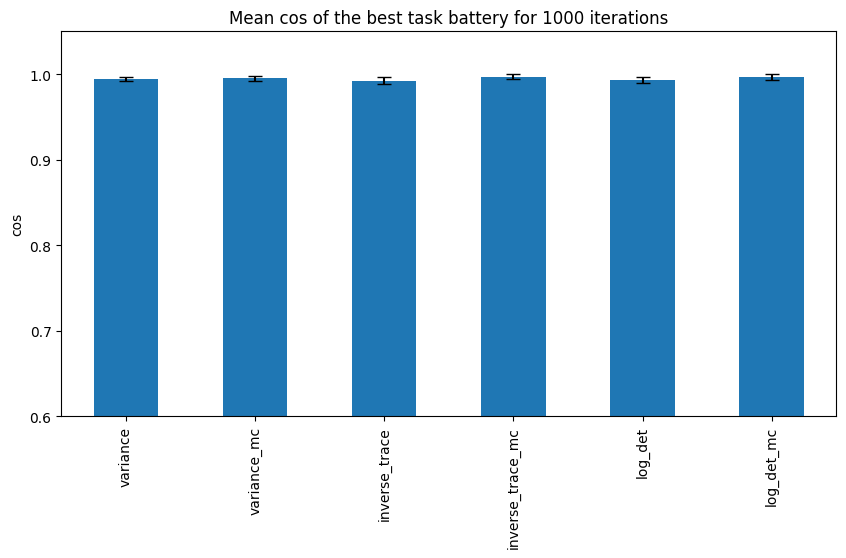

In [135]:
# plot the means as a bar plot
fig, ax = plt.subplots(figsize=(10, 5))
output_df.mean().plot(kind='bar', ax=ax, yerr=output_df.std(), capsize=5)
# set minimum y value to 50
ax.set_ylim(bottom=0.6)
ax.set_ylabel(eval_metric)
ax.set_title(f'Mean {eval_metric} of the best task battery for {num_iterations} iterations')
plt.show()
